# <center> Formation au webscrapping avevc Python </center>
## <center> Partie 2 - Scrapping Dynamique </center>
## <center>  Alioscha Massein (Maison des Sciences de l'Homme - Lyon Saint Etienne) <br/></center> 

# 1. Dynamisez votre collecte !

## 1.1 Statique vs Dynamique

Nous avons vu dans le premier notebook comment récupérer de l'information (*scraper*) depuis des pages web statiques, c'est-à-dire des pages web où il n'y a pas de formulaires de saisie, pas de génération d'HTML côté serveur, pas ou peu de javascript pour générer et mettre en forme les données issues, par exemple, d'une API ou d'une base données. 
Une page web dites **statique** est une site internet où les pages HTML du site et l'entiéreté du code **pré-existent** à la connection du client. Pour le dire autrement, la page web ne varie pas en fonction de l'utilisateur ou de l'interaction avec le site. Ces sites peuvent utiliser les mêmes technologies que les pages dynamiques (HTML, CSS, JavaScript...) mais ce code est exécuté en amont sur le serveur, au moment de la connection et est intégré à une page HTML qui est directement envoyé au client. 
Du coup, une page web **dynamique**, c'est une page où les composants de la page web HTML sont générés lors des interactions avec avec le client. En pratique, ça signifie que l'ensemble de l'information n'est pas à disposition dans la page HTML directement : cette information se révèle en fonction de l'interaction avec le client (scroll, clique...). Dans certains cas, la page HTML qui est renvoyée est même complètement illisible, car elle n'intègre que des balises `<script>`, qui vont elles générer le contenu HTML final. Ce sont des mesures de sécurité mises en place par certains sites web pour éviter de scraper leur plateforme. Les pages dynamiques sont donc plus complexes à scraper car il faut souvent attendre que le JavaScript s'exécute, ou que les données soient chargées depuis une API. Donc cela suppose que de récupérer uniquement le HTML avec requests ne nous permet pas de récupérer les données que l'on souhaite.

Voici un petit exemple :

In [2]:
import requests

<!DOCTYPE html><html class="_9dls _ar44" lang="en" dir="ltr"><head><link data-default-icon="https://static.cdninstagram.com/rsrc.php/yr/r/rzWiSjZRxk5.webp" rel="icon" sizes="192x192" href="https://static.cdninstagram.com/rsrc.php/yr/r/rzWiSjZRxk5.webp" /><meta name="bingbot" content="noarchive" /><meta name="robots" content="noarchive, noimageindex" /><meta charset="utf-8" /><meta name="apple-mobile-web-app-status-bar-style" content="default" /><meta name="mobile-web-app-capable" content="yes" /><meta id="viewport" name="viewport" content="width=device-width, initial-scale=1, minimum-scale=1, maximum-scale=2, viewport-fit=cover" /><meta name="theme-color" content="#ffffff" /><meta name="theme-color" content="#000000" media="(prefers-color-scheme: dark)" /><link rel="apple-touch-icon" sizes="76x76" href="https://static.cdninstagram.com/rsrc.php/yj/r/f01UdNyJjJj.webp" /><link rel="apple-touch-icon" sizes="120x120" href="https://static.cdninstagram.com/rsrc.php/yL/r/mMvhX4currF.webp" /><l
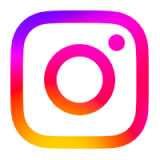
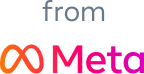

In [20]:
res = requests.get("https://instagram.com")
print(res.text)

Alors ? Qu'est-ce que l'on peut faire de ces données ?
On voit bien qu'il n'y a que des balises \<script\>, mais pas de données ou d'information que l'on peut récupérer. En fait, les informations sont générés *dynamiquement* par du Javascript qui est interprété côté client. Il faut donc un client qui est capable de lire, et d'interpréter le code en Javascript. Une petite idée ?
Et oui, il s'agit de... votre navigateur préféré ! En plus de lire le code HTML, les feuilles de style css, votre navigateur execute le code javascript et produit le code HTML nécessaire. Pour la page ci-dessus vous pouvez allez voir le code depuis l'inspecteur de votre navigateur.
La vraie contrainte de ce type de page est lié à la récupération des données. Étant donnée qu'elles ne sont pas générés automatiquement par le serveur en amont, il faut que le client web les récupères et les intègre. Cela peut se faire de deux manières : 
- Soit en récupérant les données via une API, et en intégrant les résultats des requêtes XHR / Fetch. Mais dans ce cas, on peut être confronté à des problèmes d'authentification ou de CORS (Cross-origin resource sharing).
- Soit en lisant les données directement stockées dans le DOM (c'est-à-dire la page web au sens de JS) dans un format json

Oui, donc pas aussi simple que les pages statistiques... Mais est-ce qu'il n'y aurait pas un moyen de reproduire le comportement d'un navigateur avec un peu de code ? 

## 1. 2. Selenium

### 1.2.1 Installation de Selenium

Et bien si ! Et bien heureusement, sinon tout ce qu'on a appris tout précédemment ne serait valable que pour les sites statiques. **Selenium** est un outil qui permet de simuler un navigateur web en nous permettant de reproduire tous les comportements classiques d'un utilisateur. Par exemple, on peut ouvrir une page web, cliquer sur des éléments, scroller vers un endroit, remplir des formulaires, etc... et c'est tout sa force. On peut utiliser Selenium avec plusieurs langages, mais nous allons ici utiliser la version python. 
Par contre, il faut ajouter quelques installations supplémentaires à notre ordinateur. En particulier, Selenium a besoin que l'on installe un *driver* de votre navigateur préféré. Je vous conseille d'installer le driver qui correspond à votre navigateur par défaut, pour mieux vous repérer. Vous trouverez les drivers correspondant sur les pages correspondantes : 
- [Firefox](https://github.com/mozilla/geckodriver/releases)
- [Chrome](https://chromedriver.chromium.org/)
- [Safari](https://webkit.org/blog/6900/webdriver-support-in-safari-10/)
- [Edge](https://developer.microsoft.com/en-us/microsoft-edge/tools/webdriver/) 
Si vous utilisez MacOs, ou Linux et Firefox, je vous conseille d'utiliser `HomeBrew` pour gérer vos installations. 
```zsh
brew install geckodriver
```
Vous pouvez sinon suivre les spécifications d'installation pour chacun des drivers (ajout de l'information dans le `PATH`...). Dans notre cas, je vous invite à télécharger le driver qui correspond à votre navigateur et, le temps de la formation, mettre le driver dans le dossier de cette formation. Et puis je vous conseille aussi de ne pas utiliser de logiciel propriétaire ! Exit Chrome, bienvenue Firefox !

Il faut ensuite installer les librairies python qui permettent d'interagir avec Selenium : 
````zsh
uv add selenium
# Ou avec pip
pip install selenium
````

Pour vérifier que tout fonctionne pour le mieux, on peut tenter de lancer un client web avec Selenium, pour voir s'il est bien installé : 

In [3]:
from selenium import webdriver
from selenium.webdriver.common.by import By

In [67]:
driver = webdriver.Firefox()
#driver = webdriver.Chrome()
driver.get("https://www.msh-lse.fr/")

Si la page de la MSH apparaît, c'est que tout fonctionne ! La ligne suivante permet de créer un navigateur, à partir duquel on va pouvoir naviguer et manipuler des pages web :
````python
from selenium import webdriver
driver = webdriver.Firefox()
````
On peut ensuite ferme le driver avec une commande simple :

In [110]:
driver.quit()

### 1.2.2 Fonctions essentiels de Selenium

L'avantage de Selenium (en plus du côté ludique de voir un petit robot agir dans un navigateur) est de pouvoir interagir avec le navigateur de la même manière que vous le feriez. Mais en premieur lieu, Selenium nous permet déjà de récupérer le code HTML d'une page web. Prenons l'exemple que nous avons vu plus tôt de page uniquement composée de balise `<script>` :

In [132]:
url = "https://scrollmagic.io/examples/advanced/infinite_scrolling.html"
res = requests.get(url)
#print(res.text)

Avec `requests` on ne voit que des balises script et un tout petit peu de HTML... qui appel un fichier javascript ! Essayons maitenant avec Selenium :

In [133]:
driver = webdriver.Firefox()
driver.get(url)
elem = driver.find_element(By.TAG_NAME, "html")
#print(elem.get_attribute('innerHTML'))

Bon et ben c'est la même chose ! Du coup pas très utile Selenium... Mais c'est surtout parce que l'on n'exploite pas encore les possibilités de Selenium !
Commentons le petit bout de code ci-dessus : 
````python
driver.get(url)
elem = driver.find_element(By.TAG_NAME, "html")
````
Avec ce bout de code, on va d'abord naviguer à l'adresse url stockées dans la variable `url`. On cherche ensuite la balise `html` dans le document HTML auquel nous avons accès que l'on stocke dans l'objet `elem`. On utilise la fonction `By` pour choisir le type d'élément que l'on cherche. On peut aussi chercher par `ID`, `CLASS_NAME`, `NAME`, `TAG_NAME`, `CSS_SELECTOR`, `LINK_TEXT`, `PARTIAL_LINK_TEXT`, `XPATH`... vous trouverez toutes les informations dans la documentation de [Selenium-python](https://selenium-python.readthedocs.io/locating-elements.html).
On peut ensuite manipuler elem pour y faire plusieurs choses, notamment récupérer son contenu HTML. On pourrait faire pleins d'autres choses, notamment récupérer par exemple tout le texte de cette balise :

In [14]:
print(elem.text)

BASIC
ADVANCED
EXPERT
◄
►
Infinite Scrolling
Dynamic content pages become scroll magical.
An infinite-content page can be achieved by adding a scene that triggers at the bottom of the page.
On Scene start enter loading state. Save the state to prevent multiple triggers. In this example the class of the #loader element is used.
Make ajax call to load additional content (if not already in loading state).
When receiving the ajax "load" event, add the content to your container, update the scene and revert to original state.
The demo below doesn't really use ajax to ensure offline compatibility. Instead it uses a function to immitate an ajax call to add content.
view source


Un `driver` Selenium est un navigateur web avec lequel on peut interagir, et récupérer des informations à partir des éléments que l'on trouve dans le HTML. Vous savez ce que ça veut dire ? Que l'on va rouvrir **l'inspecteur** dans le client Selenium pour aller voir les éléments que l'on veut récupérer !
Par exemple, essayons de récupérer l'ensemble de la `div` avec l'`id` "content"

In [36]:
div = driver.find_element(By.ID, "content")
print(div.get_attribute('id'))
boxes = div.find_elements(By.CLASS_NAME, "box1")
print(f"Number of boxes : {len(boxes)}")

content
Number of boxes : 27


Cette fois, on a bien accès aux éléments de la page web ! Et c'est là toute la force de Selenium : on peut récupérer des éléments qui ont été interprétés par le navigateur. On peut également interagir avec les éléments de la page pour afficher des informations qui ne sont pour l'instant pas disponible. Par exemple, cliquons sur le lien `view source` :

In [27]:
link = driver.find_element(By.CLASS_NAME, "viewsource")
link.click()

Et voilà ! On a modifié le code HTML de la page en interagissant avec, et on peut récupérer les informations qui ont été nouvellement générée. 

### Exercice 1

D'ailleurs je vous invite à récupérer le texte (code) qui a été affiché à l'écran, et à ferme la fenêtre créé en cliquant sur la flèche en haut à droite. 

In [ ]:
## EXERCICES
text = driver.find_element(By.CLASS_NAME, "code")
print(text)
close_windows = driver.find_element(By.ID, "close")
close_windows.click()

### 1.2.3 Applications de Selenium

Maintenant que l'on a vu quelques fonctions essentielles pour Selenium, nous allons voir comment l'on peut utiliser des fonctionnalités plus avancées pour interagir avec la page et récupérer de l'information qui est cachée avant l'interaction avec la page. Dans le cas de notre page d'exemple, nous souhaitons récupérer la couleur de l'élément. On peut le faire pour nos 27 premiers éléments en récupérant l'attribut `style` de chaque *box*. 

In [ ]:
div = driver.find_element(By.ID, "content")
boxes = div.find_elements(By.CLASS_NAME, "box1")
for i, box in enumerate(boxes):
    color = box.get_attribute("style").replace("background-color: ", "") #On peut récupérer les informations des balises avec la fonction get_attribute. Pratiques pour récupérer des liens !
    print(f"{i} - Color : {color}")

0 - Color : rgb(175, 225, 137);
1 - Color : rgb(216, 76, 173);
2 - Color : rgb(90, 224, 41);
3 - Color : rgb(215, 70, 188);
4 - Color : rgb(100, 108, 77);
5 - Color : rgb(116, 57, 74);
6 - Color : rgb(238, 129, 30);
7 - Color : rgb(14, 204, 1);
8 - Color : rgb(90, 157, 39);
9 - Color : rgb(232, 101, 111);
10 - Color : rgb(168, 231, 3);
11 - Color : rgb(245, 134, 78);
12 - Color : rgb(54, 115, 65);
13 - Color : rgb(153, 117, 220);
14 - Color : rgb(207, 79, 7);
15 - Color : rgb(179, 207, 212);
16 - Color : rgb(46, 251, 56);
17 - Color : rgb(237, 94, 201);
18 - Color : rgb(34, 6, 245);
19 - Color : rgb(117, 5, 220);
20 - Color : rgb(173, 249, 62);
21 - Color : rgb(89, 138, 160);
22 - Color : rgb(137, 186, 14);
23 - Color : rgb(204, 40, 210);
24 - Color : rgb(202, 221, 238);
25 - Color : rgb(243, 106, 194);
26 - Color : rgb(221, 203, 217);


Comme vous avez du pouvoir le lire sur la page web, il s'agit d'une page avec scroll infini. On sait donc qu'il y a plus que 27 éléments à récupérer ! On va donc scroller jusqu'en bas de la page pour faire charger les éléments suivants. On doit utiliser un bout de JavaScript pour scroller jusqu'à la vue.

In [12]:
# from selenium.webdriver.common.action_chains import ActionChains
downPage = driver.find_element(By.ID, "loader")
# ActionChains(driver).move_to_element(downPage).perform()
driver.execute_script("arguments[0].scrollIntoView(true);", downPage)

Regardons maintenant la longueur de notre liste `boxes` :

In [14]:
boxes = driver.find_elements(By.CLASS_NAME, "box1")
print(len(boxes))

36


On voit que le nombre a changé ! En scrollant vers le bas, on a chargé de nouveaux éléments, que l'on peut maintenant scrapper. Bon le problème du scroll infini, c'est bien qu'il est infinie.

### Exercice 2

Essayez de récupérer les couleurs pour les 5 prochains scrolls. Attention ! Les éléments ne se chargent pas forcément instantanément, il faut que le script qui créé les `box` aient le temps de s'éxecuter.

In [134]:
# EXERCICE
import time
driver.get(url)
nb_range = 5
for i in range(nb_range):
    downPage = driver.find_element(By.ID, "loader")
    driver.execute_script("arguments[0].scrollIntoView(true);", downPage)
    boxes = driver.find_elements(By.CLASS_NAME, "box1")
    print(f"{i} : {len(boxes)}")
    if i < nb_range-1:
        time.sleep(2) #On doit ajouter un timer pour être sur que l'élément s'affiche bien !
boxes = [box.get_attribute("style").replace("background-color: ", "") for box in boxes]
print(len(boxes))
print(boxes)

0 : 18
1 : 27
2 : 36
3 : 45
4 : 54
54
['rgb(123, 235, 87);', 'rgb(144, 75, 177);', 'rgb(13, 195, 64);', 'rgb(154, 49, 34);', 'rgb(186, 79, 211);', 'rgb(235, 31, 2);', 'rgb(77, 114, 194);', 'rgb(4, 193, 25);', 'rgb(22, 58, 127);', 'rgb(196, 127, 184);', 'rgb(184, 42, 35);', 'rgb(4, 79, 56);', 'rgb(232, 50, 226);', 'rgb(204, 228, 182);', 'rgb(134, 46, 211);', 'rgb(70, 187, 178);', 'rgb(30, 188, 121);', 'rgb(99, 50, 157);', 'rgb(144, 192, 41);', 'rgb(248, 224, 240);', 'rgb(67, 66, 172);', 'rgb(93, 230, 203);', 'rgb(111, 60, 16);', 'rgb(79, 13, 188);', 'rgb(104, 230, 33);', 'rgb(49, 186, 91);', 'rgb(140, 56, 138);', 'rgb(130, 177, 116);', 'rgb(137, 165, 220);', 'rgb(182, 23, 233);', 'rgb(154, 36, 216);', 'rgb(176, 254, 76);', 'rgb(238, 200, 157);', 'rgb(187, 244, 255);', 'rgb(247, 60, 184);', 'rgb(71, 59, 150);', 'rgb(31, 82, 92);', 'rgb(155, 135, 159);', 'rgb(159, 51, 137);', 'rgb(51, 129, 8);', 'rgb(166, 127, 217);', 'rgb(239, 4, 42);', 'rgb(57, 115, 61);', 'rgb(193, 210, 134);', 'rgb(12

### 1.2.4 Attendre le chargement d'un élément

Pour que les éléments s'affichent bien sur une page, on veut laisser le temps aux pages de se charger, sinon les éléments sont absents, pas encore existants... ce comportement est lié à une propriété intrinsèque de nombreuses pages web : le comportement **asynchrone**. Sur la plupart des pages web, des éléments sont chargés à distance, comme des données données stockées dans un serveur SQL, des images distantes sur un autre serveur, une requête de l'utilisateur en attente... donc on attend souvent que ces éléments soient fournis à l'application web avant d'effectuer un ensemble d'autre tâches. Cela signifie que tout ne s'éxecute pas l'un à la suite des autres sur une page web dynamique. Python permet également de programmer de manière asynchrone (avec les méthodes `async`,`await` du package `asyncio`), mais nous pouvons utiliser des outils intégrés à Selenium. 

Il existe donc plusieurs stratégies de nouveaux pour attendre le temps nécessaire pour que les éléments est chargés : 
- D'abord la solution que l'on a vu au dessus, c'est-à-dire dire de fixer des timer à intervalle régulier. Cette solution est celle qui est la plus simple pour forcer une attente, mais elle n'est pas forcément la plus pratique car les éléments peuvent charger à des vitesses différentes. ELle a l'inconvénient de beaucoup rallonger les temps de traitement de l'information. 
- Une autre solution est implémenté dans Selenium, et permet d'attendre spécifique qu'un élément spéficique soit chargé avant d'effectuer d'autres opérations. On doit importer un nouveau module : 
````python
from selenium.webdriver.support.wait import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC

wait = WebDriverWait(driver, timeout=5) #le temps est en seconde
wait.until(EC.visibility_of_element_located((By.ID, "the_element")))
````

- Enfin, une troisième solution permet de créer une stratégie a priori pour chaque élément et permet d'emblée de fixer un temps d'attente
````python
driver.implicitly_wait(2)
````
Avec cete méthode, on attendra au maximum 2 secondes pour chaque élément, et on ne fera pas de test sur l'élément en question. Cela permet de gérer les cas où l'élément n'est pas encore chargé, mais cela ne permet pas de tester si un élément est bien chargé.

## 1.3 Exemple concret

### 1.3.1 un premier vrai test

Dans de nombreux cas, on cherche de l'information qui est paginée, c'est-à-dire qui n'est pas entièrement disponible sur une page. Il faut aller de page en page pour récupérer l'information. C'est souvent le cas pour les sites d'informations, les moteurs de recherche, les sites de ventes, les commentaires d'un produit, etc...
Dans ce cas, il y a souvent plusieurs manières de faire, mais profitons des possibilités offertes par Selenium : il y a souvent un bouton cliquable qui permet de naviguer d'une page à l'autre. On peut donc cliquer sur ce bouton tant qu'il est disponible afin de parcourir toutes les pages sur un contenu. 
Pour cette exercice, nous allons nous intéresser au site d'annonce d'[emploi de la métropole de Lyon](https://www.grandlyon.com/mes-services-au-quotidien/travailler-a-la-metropole/les-offres-demploi-stage-et-apprentissage).

In [ ]:
url = "https://www.grandlyon.com/mes-services-au-quotidien/travailler-a-la-metropole/les-offres-demploi-stage-et-apprentissage"
driver.get(url)

Si on descend en bas de la page, on voit une balise `<ul class ="pagination--items">` qui contient les informations de pagination pour les différentes pages de la recherche. On va se servir du bouton qui permet de naviguer dans les pages suivantes. On aurait aussi bien pu observer la forme que prend l'url quand on navigue à travers les pages et utiliser le dernier élément de la liste pour naviguer de page en pagen surtout si l'information est disponible via requests, ce qui est le cas ici. Mais restons avec Selenium. On va pouvoir se servir de Selenium pour naviguer à travers les pages et récupérer l'information que l'on va stocker dans un dictionnaire par exemple. 

### Exercice 3

Écrivez le code qui vous permet de récupérer tous les éléments visuellement disponibles pour chaque offre d'emploi sur la première page.

In [ ]:
# EXERCICE
start_url = "https://www.grandlyon.com/mes-services-au-quotidien/travailler-a-la-metropole/les-offres-demploi-stage-et-apprentissage"
driver = webdriver.Firefox()
driver.get(start_url)
emplois = []
emplois.extend([elem.text for elem in driver.find_elements(By.CLASS_NAME, "joboffer__item")])
print(emplois)

["Assistant administratif enfance (H/F)\nREDACTEURS TERRITORIAUX\nRéf. : 2026-14991\nService : Délégation solidarités, habitat et éducation, Territoire Lyon Rive Droite, Maison de la Métropole de Lyon 9ème, service enfance\nDate de fin de candidature : 27/05/2026\nVoir l'offre", "Chargé de mission volet habitat Nouveau Programme National de Renouvellement Urbain (H/F)\nATTACHES TERRITORIAUX\nRéf. : 2026-14995\nService : Délégation solidarités, habitat et éducation, Direction Habitat et Logement, service développement et renouvellement de l'offre d'habitat, unité gestion dispositifs développement habitat\nDate de fin de candidature : 27/05/2026\nVoir l'offre", "Conseiller qualité sécurité environnement (H/F)\nTECHNICIENS TERRITORIAUX\nRéf. : 2026-15000\nService : Délégation transition environnementale et énergétique, Direction Cycle de l'Eau, station d'épuration d'Oullins-Pierre-Bénite, cellule QSE\nDate de fin de candidature : 27/05/2026\nVoir l'offre", "Responsable maintenance station

Maintenant que l'on a récupéré l'information sur la page, il faut passer à la page suivante, et recommencer.

In [116]:
# Exercice
next_page = driver.find_element(By.CLASS_NAME, "next")
next_page.click()
emplois.extend([elem.text for elem in driver.find_elements(By.CLASS_NAME, "joboffer__item")])
print(len(emplois))

ElementClickInterceptedException: Message: Element <li class="next pagination-link pagination-link--next"> is not clickable at point (874,699) because another element <div id="tarteaucitronAlertBig" class="tarteaucitronAlertBigBottom"> obscures it
Stacktrace:
RemoteError@chrome://remote/content/shared/RemoteError.sys.mjs:8:8
WebDriverError@chrome://remote/content/shared/webdriver/Errors.sys.mjs:202:5
ElementClickInterceptedError@chrome://remote/content/shared/webdriver/Errors.sys.mjs:354:5
webdriverClickElement@chrome://remote/content/marionette/interaction.sys.mjs:175:11
interaction.clickElement@chrome://remote/content/marionette/interaction.sys.mjs:134:11
clickElement@chrome://remote/content/marionette/actors/MarionetteCommandsChild.sys.mjs:333:29
receiveMessage@chrome://remote/content/marionette/actors/MarionetteCommandsChild.sys.mjs:205:31


Mais on se retrouve face à une erreur ! Est-ce que vous comprenez à quoi elle est dû ?

### 1.3.2 Gérer les évènements supplémentaires

Souvent, sur une page web, il y a des éléments qui peuvent superposer d'autres éléments : une pop-up qui vient masquer le contenu, un bandeau qui se superposent à un titre... de fait, pour accéder et cliquer sur un élément qui est situé en-dessous, il nous faut d'abord enlever l'élément au premier plan.
Depuis quelques années, des bandeaux de cookies apparaissent au cours de notre navigation. Quand on charge les pages de manières instantanées, ce n'est pas un souci, car souvent, cet élément n'a pas le temps de se charger. Mais dès lors qu'on réalise plusieurs actions, on a envie de se retirer cet épine du pied. Ici l'erreur suivante : 
> Message: Element `<li class="next pagination-link pagination-link--next">` is not clickable at point (874,702) because another element `<div id="tarteaucitronAlertBig" class="tarteaucitronAlertBigBottom">` obscures it

nous dit que le bandeau des cookies est au dessus de l'élément sur lequel on souhaite cliquer, et donc qu'on ne peut pas cliquer dessus ! Deux solutions s'offrent alors à nous :
- Soit cliquer sur un bouton du bandeau pour accepter ou refuser les cookies
- Soit scroller de manière à ce que l'élément soit visible

On va utiliser la première façon de faire avec des fonctions un peu spéciale de Selenium qui permettent de créer des chaînes d'actions avec une méthode :
````python
ActionChains()
````
En fait, de la même manière que l'on a jusqu'ici fait les actions une par une, `ActionChains` permet de créer une série d'inputs que l'on va pouvoir utiliser avec la méthode `perform()`. On crée alors notre série d'action : 
````python
actionToDo = ActionChains(driver).move_to_element(element).click(element)
actionToDo.perform()
````

In [135]:
from selenium.webdriver.common.action_chains import ActionChains

# On instancie le navigateur
driver = webdriver.Firefox()
driver.implicitly_wait(2)
emplois = []

# On charge la page et on gère la question des cookies
driver.get(start_url)
deny = driver.find_element(By.ID, "tarteaucitronAllDenied2")
cookiesActions = ActionChains(driver).move_to_element(deny).click(deny)
cookiesActions.perform()


emplois.extend([elem.text for elem in driver.find_elements(By.CLASS_NAME, "joboffer__item")])
print(len(emplois))

next_page = driver.find_element(By.CLASS_NAME, "next")
next_page.click()
emplois.extend([elem.text for elem in driver.find_elements(By.CLASS_NAME, "joboffer__item")])
print(len(emplois))
driver.quit()

12
24


Et voilà ! On a enlever le beandeau des cookies et on est passé d'une page à l'autre. 
En fait, les actions que l'on souhaite réaliser avec Selenium sont plus facilement réalisables avec la fonction `ActionChains`, c'est d'ailleurs la bonne manière de faire. Pas mal de comportement sont déjà implémentés dans des méthodes, comme le clique, le déplacement de la souris, le double clique, la saisie de texte avec le clavier... vous pouvez retrouvez les différentes méthodes sur la [documentation de Selenium](https://www.selenium.dev/documentation/webdriver/actions_api/).

### Exercice 4

Bon c'est super tout ça, mais on va pas cliquer sur les deux cellules jusqu'à arriver au bout du processus. On va créer un petit algorithme qui récupère toutes les informations de chaque page et qui s'arrête quand il est arrivé à la dernière page. On va donc créer une boucle qui permet de faire ces étapes et qui s'arrête quand elle ne peut plus cliquer plus loin. 

In [138]:
# Exercice
start_url = "https://www.grandlyon.com/mes-services-au-quotidien/travailler-a-la-metropole/les-offres-demploi-stage-et-apprentissage"
driver = webdriver.Firefox()
driver.implicitly_wait(2)
driver.get(start_url)
emplois = []

deny = driver.find_element(By.ID, "tarteaucitronAllDenied2")
cookiesActions = ActionChains(driver).move_to_element(deny).click(deny)
cookiesActions.perform()

i = 1
max_page = int(driver.find_element(By.CLASS_NAME, "last").text)
print(f"MAX PAGE : {max_page}")
while i <= max_page:
    print(f"\rPage {i}/{max_page}", end="")
    emplois.extend([elem for elem in driver.find_elements(By.CLASS_NAME, "joboffer__item")])
    next_page = driver.find_element(By.CLASS_NAME, "next")
    next_page.click()
    i += 1

driver.quit()
print("\n", len(emplois))

MAX PAGE : 14
Page 14/14
 157


Ici nous utilisons le nombre de pages, parce que c'est une information disponible, mais ce n'est pas tout le temps le cas. Des fois, il faut utiliser d'autres éléments, comme par exemple le fait qu'un bouton soit actif ou inactif, l'apparition d'une balise particulière...

### Exercice 5

Pour finir cet exercice, je vous invite à développer une fonction qui permet d'extraire les informations des éléments et de stocker toutes les informations concernent les emplois dans un dictionnaire.

In [139]:
def extract_infos(offre):
    dictionnaire_emploi = {
        'titre' : offre.find_element(By.TAG_NAME, "h3").text,
        'link' : offre.find_element(By.TAG_NAME, "a").get_attribute("href"),
    }
    list_infos = offre.find_element(By.TAG_NAME, 'p').text.split("\n")
    dictionnaire_emploi["Corps"] = list_infos[0]
    dictionnaire_emploi["Ref"] = list_infos[1]
    dictionnaire_emploi["Services"] = list_infos[2]
    dictionnaire_emploi["Date_fin"] = list_infos[3]

    #print(json.dumps(dictionnaire_emploi, indent=4, ensure_ascii=False))
    return(dictionnaire_emploi)

In [140]:
# Exercice
start_url = "https://www.grandlyon.com/mes-services-au-quotidien/travailler-a-la-metropole/les-offres-demploi-stage-et-apprentissage"
driver = webdriver.Firefox()
driver.implicitly_wait(2)
driver.get(start_url)
emplois = []

deny = driver.find_element(By.ID, "tarteaucitronAllDenied2")
cookiesActions = ActionChains(driver).move_to_element(deny).click(deny)
cookiesActions.perform()

i = 1
max_page = int(driver.find_element(By.CLASS_NAME, "last").text)
print(f"MAX PAGE : {max_page}")
while i <= max_page:
    print(f"\rPage {i}/{max_page}", end="")
    emplois.extend([extract_infos(elem) for elem in driver.find_elements(By.CLASS_NAME, "joboffer__item")])
    next_page = driver.find_element(By.CLASS_NAME, "next")
    next_page.click()
    i += 1

driver.quit()
print("\n", len(emplois))

MAX PAGE : 14
Page 14/14
 157


In [ ]:
import json
print(json.dumps(emplois, indent=4, ensure_ascii=False))

[
    {
        "titre": "Assistant administratif de gestion (H/F)",
        "link": "https://www.grandlyon.com/offre-emploi/2026-14949-assistant-administratif-de-gestion-h-f/fiche",
        "Corps": "ADJOINTS ADMINISTRATIFS",
        "Ref": "Réf. : 2026-14949",
        "Services": "Service : Délégation ressources humaines et moyens généraux, Service maintenance bâtiments métropolitains, unité hôtel de la métropole",
        "Date_fin": "Date de fin de candidature : 28/05/2026"
    },
    {
        "titre": "Chef de projets usine - CDD 12 mois (H/F) - CDD 12 mois mois",
        "link": "https://www.grandlyon.com/offre-emploi/2026-14992-chef-de-projets-usine-cdd-12-mois-h-f/fiche",
        "Corps": "INGENIEURS TERRITORIAUX",
        "Ref": "Réf. : 2026-14992",
        "Services": "Service : Délégation transition environnementale et énergétique, Service pilotage eaux usées - eaux pluviales - GEMAPI, unité usines méthanisation",
        "Date_fin": "Date de fin de candidature : 28/05/2026

Enfin, sauvegardez les résultats dans un fichier `scrap_dynamique.json`.

In [ ]:
with open() as f:
    json.dump()

## 1.4 Sur un moteur de recherche

In [ ]:
#url = "https://www.courdecassation.fr/recherche-judilibre"
# url = "https://www.courdecassation.fr/recherche-judilibre?search_api_fulltext=Vol+%C3%A0+l%27arrach%C3%A9e&date_du=&date_au=&judilibre_juridiction=all&op=Rechercher+sur+judilibre"
# res = requests.get(url)
# print(res.text)

In [38]:
service = webdriver.FirefoxService(executable_path="/opt/homebrew/Cellar/geckodriver/0.36.0/bin/geckodriver")
driver = webdriver.Firefox(service = service)

## 1.5 D'autres outils

### 1.5.1 Playwright

https://playwright.dev/python/docs/intro

### 1.6 autres considérations

- Gestion des cookies
- Gestion des Profiles / Services (Initialisation d'un driver)
- [Détectable / indétectable](https://stackoverflow.com/questions/58873022/how-can-i-make-a-selenium-script-undetectable-using-geckodriver-and-firefox-thro)
- Limite de WebDriver 
- Autres types d'approche : 
    - [PyDoll](https://github.com/autoscrape-labs/pydoll)
    - [ZenDriver](https://github.com/cdpdriver/zendriver)